## 1. Environment Setup & Global Configuration
We isolate all installations, imports, and hardcoded values at the top of the notebook. By changing the `target_product` in the `CONFIG` dictionary, this entire pipeline can be repurposed for Life Insurance or Mortgages.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score, classification_report
import warnings

# Suppress scientific notation and safely handle warnings
pd.set_option('display.float_format', lambda x: '%.2f' % x)
warnings.filterwarnings('ignore', category=UserWarning)

# ==========================================
# GLOBAL CONFIGURATION
# ==========================================
CONFIG = {
    "data_paths": {
        "clients": "BANK_CLIENT_clean.csv",
        "products": "BANK_PRODUCTS_clean.csv",
        "transfers": "BANK_TRANSFER_clean.csv",
        "wealth": "BANK_WEALTH_clean.csv"
    },
    "target_product": "N_CREDIT_CARD", # Change to N_LIFE_INSURANCE for a different model
    "timeline": {
        "train_anchors": [201808, 201809], # Late Summer / Early Fall
        "valid_anchors": [201810],         # Mid-Fall
        "test_anchors": [201811],          # Winter (Out-Of-Time)
        "obs_window_months": 6,
        "perf_window_months": 3
    },
    "model_params": {
        "iterations": 1000,
        "learning_rate": 0.05,
        "depth": 6,
        "random_seed": 42
    },
    "marketing": {
        "top_percentile_cutoff": 0.10,
        "campaign_cost_per_contact": 2.50,  # e.g., Cost of direct mail + operational overhead
        "expected_ltv_credit_card": 150.00  # e.g., First-year projected revenue of a new card
    }
}

In [6]:
!pip install xgboost

In [7]:
!pip install catboost

## 2. Data Ingestion and Pre-processing
Load the four core datasets provided by the bank: Client Demographics, Product Holdings, Transfer Behavior, and Wealth Snapshots. For Client dataset, the function loads client data and calculates age/tenure relative to a base year.

In [9]:
def load_and_prep_clients(path):
    """Loads client data and calculates age/tenure relative to a base year."""
    clients = pd.read_csv(path)
    clients['DATE_OF_BIRTH'] = pd.to_datetime(clients['DATE_OF_BIRTH'], errors='coerce')
    clients['REGISTRATION_DATE'] = pd.to_datetime(clients['REGISTRATION_DATE'], errors='coerce')
    
    # Base year for tenure/age calculation
    base_year = 2018 
    clients['AGE'] = base_year - clients['DATE_OF_BIRTH'].dt.year
    clients['TENURE_YEARS'] = base_year - clients['REGISTRATION_DATE'].dt.year
    
    # Fill categorical missing values safely
    clients['REGION'] = clients['REGION'].fillna('UNKNOWN').astype(str)
    clients['GENDER'] = clients['GENDER'].fillna('UNKNOWN').astype(str)
    
    return clients[['CUSTOMER_ID', 'AGE', 'TENURE_YEARS', 'REGION', 'GENDER']]

In [10]:
print("Loading Core Datasets...")
clients_df = load_and_prep_clients(CONFIG["data_paths"]["clients"])
products_df = pd.read_csv(CONFIG["data_paths"]["products"])
transfers_df = pd.read_csv(CONFIG["data_paths"]["transfers"])
wealth_df = pd.read_csv(CONFIG["data_paths"]["wealth"])
print("Data loading complete.")

Loading Core Datasets...
Data loading complete.


### Formatting
We adjust pandas global settings to suppress scientific notation, making financial figures and probabilities easier to read by rounding them to two decimal places.

In [11]:
# Suppress scientific notation globally and set to 2 decimal places
pd.set_option('display.float_format', lambda x: '%.2f' % x)

### 2.1 Exploratory Data Analysis
Inspecting the main tables of the dataset

In [12]:
clients_df.head()

,CUSTOMER_ID,AGE,TENURE_YEARS,REGION,GENDER
0,DF00261884,31,6,EMILIA ROMAGNA,M
1,IQ00262656,34,1,SARDEGNA,M
2,QA00262675,43,10,CAMPANIA,F
3,IX00262687,48,1,VENETO,F
4,AA00263211,39,17,UMBRIA,M


In [14]:
clients_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14241 entries, 0 to 14240
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   CUSTOMER_ID   14241 non-null  object
 1   AGE           14241 non-null  int32 
 2   TENURE_YEARS  14241 non-null  int32 
 3   REGION        14241 non-null  object
 4   GENDER        14241 non-null  object
dtypes: int32(2), object(3)
memory usage: 445.2+ KB


In [13]:
products_df.head()

,CUSTOMER_ID,MONTH,N_ACCT,N_MNG_ACCT,N_SAVING_DEPOSIT,N_BONDS,N_SHARES,N_FUNDS,N_LIFE_INSURANCE,N_MORTGAGE,N_FINANCING,N_WATER,N_LIGHT,N_GAS,N_TELEFONE,N_DEBIT_CARD,N_ONLINE_BANKING,N_CREDIT_CARD,N_SICAV_FUNDS,N_PENSION_FUNDS
0,DF00261884,201803.00,1,1,0,2,1,0,2,0,0,1,1,0,1,2,0,2,8,0
1,DF00261884,201804.00,1,1,0,2,1,0,2,0,0,1,1,0,1,2,0,2,8,0
2,DF00261884,201805.00,1,1,0,1,1,0,2,0,0,1,1,0,1,2,0,2,8,0
3,DF00261884,201806.00,1,1,0,1,1,0,3,0,0,1,1,0,1,2,0,2,8,0
4,DF00261884,201807.00,1,1,0,1,1,0,3,0,0,1,1,1,1,2,0,2,8,0


In [14]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180576 entries, 0 to 180575
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   CUSTOMER_ID       180576 non-null  object 
 1   MONTH             180576 non-null  float64
 2   N_ACCT            180576 non-null  int64  
 3   N_MNG_ACCT        180576 non-null  int64  
 4   N_SAVING_DEPOSIT  180576 non-null  int64  
 5   N_BONDS           180576 non-null  int64  
 6   N_SHARES          180576 non-null  int64  
 7   N_FUNDS           180576 non-null  int64  
 8   N_LIFE_INSURANCE  180576 non-null  int64  
 9   N_MORTGAGE        180576 non-null  int64  
 10  N_FINANCING       180576 non-null  int64  
 11  N_WATER           180576 non-null  int64  
 12  N_LIGHT           180576 non-null  int64  
 13  N_GAS             180576 non-null  int64  
 14  N_TELEFONE        180576 non-null  int64  
 15  N_DEBIT_CARD      180576 non-null  int64  
 16  N_ONLINE_BANKING  18

In [15]:
transfers_df.head()

,MONTH,TRANSFER_TYPE_DES,CUSTOMER_ID,AM_CREDIT,AM_DEBIT,NUM_CREDIT,NUM_DEBIT
0,201803.00,DEPOSITS,JK00818603,0.00,0.00,0.00,0.00
1,201803.00,PENSIONS_SALARY,DM00923868,1270.00,0.00,1.00,0.00
2,201803.00,TRANSFERS_IN,QD00651127,2600.00,0.00,2.00,0.00
3,201803.00,PENSIONS_SALARY,TR00667485,779.00,0.00,1.00,0.00
4,201803.00,DEPOSITS,OO00623012,0.00,0.00,0.00,0.00


In [16]:
wealth_df.head()

,CUSTOMER_ID,MONTH,TOT_DIRECT_DEPOSIT,TOT_ASSETS_UNDER_CUSTODY,TOT_MNG_DEPOSIT,TOT_INVESTMENTS
0,ON00631111,201804,10975.00,0.00,0.00,0.00
1,ON00631111,201805,10934.00,0.00,0.00,0.00
2,ON00631111,201806,10817.00,0.00,0.00,0.00
3,ON00631111,201807,10776.00,0.00,0.00,0.00
4,ON00631111,201808,10133.00,0.00,0.00,0.00


### 2.2 Cross-Table Consistency Check
Before building our datasets, we must verify that our customer base is consistent across all tables. We observe that while 14,241 customers exist in the Client, Products, and Wealth tables, only 12,456 customers have recorded transactions in the Transfer table.

In [17]:
print("--- Unique Customers ---")
print(f"Total in Client Registry: {clients_df['CUSTOMER_ID'].nunique()}")
print(f"Total in Products Table: {products_df['CUSTOMER_ID'].nunique()}")
print(f"Total in Wealth Table: {wealth_df['CUSTOMER_ID'].nunique()}")
print(f"Total in Transfer Table: {transfers_df['CUSTOMER_ID'].nunique()}")

--- Unique Customers ---
Total in Client Registry: 14241
Total in Products Table: 14241
Total in Wealth Table: 14241
Total in Transfer Table: 12456


### 2.3 Investigating Customers without Transfers
We need to understand the behavior of the 1,785 customers missing from the Transfer table. Are they dormant accounts? We find that despite lacking transfer records, 250 of these customers still acquired a new credit card during the observation period. Therefore, we must retain them in our modeling population and impute their missing transfer features with zeros.

In [19]:
# 1. Get the list of IDs that DO have transfers
transfer_customer_ids = transfers_df['CUSTOMER_ID'].unique()

# 2. Identify the customers who have NO transfers
no_transfer_customers = clients_df[~clients_df['CUSTOMER_ID'].isin(transfer_customer_ids)]['CUSTOMER_ID']

# 3. Check their credit card ownership across the entire dataset
cc_holdings_of_dormant = products_df[products_df['CUSTOMER_ID'].isin(no_transfer_customers)]

print(f"Total customers with zero transfers: {len(no_transfer_customers)}")
print(f"Maximum credit cards held by any of these customers at any time: {cc_holdings_of_dormant['N_CREDIT_CARD'].max()}")

# See if any of them experienced an upsell (bought a card) during the 13 months
max_cards_per_dormant = cc_holdings_of_dormant.groupby('CUSTOMER_ID')['N_CREDIT_CARD'].max()
min_cards_per_dormant = cc_holdings_of_dormant.groupby('CUSTOMER_ID')['N_CREDIT_CARD'].min()
upsells = (max_cards_per_dormant > min_cards_per_dormant).sum()

print(f"Total 'No-Transfer' customers who bought a new credit card: {upsells}")

Total customers with zero transfers: 1785
Maximum credit cards held by any of these customers at any time: 8
Total 'No-Transfer' customers who bought a new credit card: 250


### Defining the Observation Timeline
To build a predictive model, we must establish a clear timeline. We have exactly 13 months of historical data, running from March 2018 through March 2019. This timeline will dictate how we construct our observation windows (historical data for features) and performance windows (future data for the target variable).

In [21]:
# Explore the timeline in the Products and Wealth tables
months_available = products_df['MONTH'].sort_values().unique()

print("--- Timeline Analysis ---")
print(f"Total number of months recorded: {len(months_available)}")
print(f"Earliest Month (YYYYMM): {months_available[0]}")
print(f"Latest Month (YYYYMM): {months_available[-1]}")
print(f"All available months: \n{months_available}")

--- Timeline Analysis ---
Total number of months recorded: 13
Earliest Month (YYYYMM): 201803.0
Latest Month (YYYYMM): 201903.0
All available months: 
[201803. 201804. 201805. 201806. 201807. 201808. 201809. 201810. 201811.
 201812. 201901. 201902. 201903.]


### Missing Value Assessment
We systematically check all dataframes for missing values. We find that only the Transfer table contains nulls, specifically in the `TRANSFER_TYPE_DES` column. We will need to handle these when pivoting transaction types during feature engineering.

In [24]:
# Define a helper function to print missing values
def check_missing_data(df, name):
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if missing.empty:
        print(f"No missing values in {name}")
    else:
        print(f"Missing values in {name}:")
        print(missing)
        print("-" * 20)

print("--- Missing Values Check ---")
check_missing_data(clients_df, "Clients DF")
check_missing_data(products_df, "Products DF")
check_missing_data(wealth_df, "Wealth DF")
check_missing_data(transfers_df, "Transfers DF")

--- Missing Values Check ---
No missing values in Clients DF
No missing values in Products DF
No missing values in Wealth DF
Missing values in Transfers DF:
TRANSFER_TYPE_DES    339322
dtype: int64
--------------------


## 3. Pipeline Core
### 3.1 Target Generation
This function determines who is eligible for a cross-sell (they don't already own the product) and checks if they acquire it during the performance window.

In [25]:
def create_propensity_target(products_df, obs_start, anchor_month, performance_months, target_col):
    """
    Creates a binary target for product acquisition, enforcing a strict stability rule 
    across the ENTIRE observation window.
    """
    # 1. Get all months within the observation window
    obs_months = [m for m in products_df['MONTH'].unique() if obs_start <= m <= anchor_month]
    
    # 2. Extract product counts during the observation window
    obs_data = products_df[products_df['MONTH'].isin(obs_months)][['CUSTOMER_ID', target_col]]
    
    # 3. Enforce STRICT STABILITY RULE
    # The max holding must equal the min holding across all 6 months
    stability_agg = obs_data.groupby('CUSTOMER_ID')[target_col].agg(['min', 'max', 'last']).reset_index()
    eligible_customers = stability_agg[stability_agg['min'] == stability_agg['max']][['CUSTOMER_ID', 'last']]
    eligible_customers.rename(columns={'last': 'ANCHOR_COUNT'}, inplace=True)
    
    assert not eligible_customers.empty, f"No eligible customers found for anchor {anchor_month}"
    
    # 4. Get product counts during the PERFORMANCE window
    perf_data = products_df[products_df['MONTH'].isin(performance_months)][['CUSTOMER_ID', target_col]]
    target_agg = perf_data.groupby('CUSTOMER_ID')[target_col].max().reset_index().rename(columns={target_col: 'MAX_PERF_COUNT'})
    
    # 5. Define Target: Did their max count in the performance window EXCEED their anchor count?
    target_df = eligible_customers.merge(target_agg, on='CUSTOMER_ID', how='left').fillna(0)
    target_df['TARGET'] = (target_df['MAX_PERF_COUNT'] > target_df['ANCHOR_COUNT']).astype(int)
    target_df['COHORT_MONTH'] = anchor_month
    
    return target_df[['CUSTOMER_ID', 'TARGET', 'COHORT_MONTH']]

### 3.2 Feature Engineering Domain Modules
By separating the logic into domain-specific functions, the code becomes modular, easier to test, and DRY.

In [26]:
def calculate_month_diff(end_month, start_month):
    """Helper to calculate the difference in months between two YYYYMM integers"""
    y1, m1 = int(end_month) // 100, int(end_month) % 100
    y2, m2 = int(start_month) // 100, int(start_month) % 100
    return (y1 - y2) * 12 + (m1 - m2)

In [27]:
def build_transfer_features(transfers_df, cohort_ids, obs_months):
    """Aggregates transactional behaviors, adding RECENCY."""
    obs_transfers = transfers_df[transfers_df['MONTH'].isin(obs_months)].copy()
    obs_transfers = obs_transfers.merge(cohort_ids, on='CUSTOMER_ID', how='inner')
    
    if obs_transfers.empty:
        # If no transactions, recency is the max window length
        cohort_ids['MONTHS_SINCE_LAST_TXN'] = len(obs_months)
        return cohort_ids 
        
    agg_features = obs_transfers.groupby('CUSTOMER_ID').agg(
        TOTAL_CREDIT_6M=('AM_CREDIT', 'sum'),
        TOTAL_DEBIT_6M=('AM_DEBIT', 'sum'),
        NUM_TXN_6M=('NUM_CREDIT', 'sum'),
        LAST_TXN_MONTH=('MONTH', 'max') # Grab the latest transaction month
    ).reset_index()
    
    # Calculate Recency
    anchor_month = obs_months[-1]
    agg_features['MONTHS_SINCE_LAST_TXN'] = agg_features['LAST_TXN_MONTH'].apply(
        lambda x: calculate_month_diff(anchor_month, x)
    )
    agg_features.drop(columns=['LAST_TXN_MONTH'], inplace=True)
    
    # Pivot Golden Signals
    pivot_txns = obs_transfers.pivot_table(
        index='CUSTOMER_ID', columns='TRANSFER_TYPE_DES', 
        values='AM_CREDIT', aggfunc='sum', fill_value=0
    )
    pivot_txns.columns = [f"SUM_CREDIT_{str(col).upper()}_6M" for col in pivot_txns.columns]
    
    return agg_features.merge(pivot_txns.reset_index(), on='CUSTOMER_ID', how='left')

In [28]:
def build_wealth_features(wealth_df, cohort_ids, obs_months):
    """Calculates wealth asset balances, trends, and VELOCITY."""
    obs_wealth = wealth_df[wealth_df['MONTH'].isin(obs_months)].copy()
    obs_wealth = obs_wealth.merge(cohort_ids, on='CUSTOMER_ID', how='inner').sort_values(['CUSTOMER_ID', 'MONTH'])
    
    latest_month = obs_months[-1]
    prior_months = obs_months[:-1]
    
    # Latest Wealth (End of window)
    latest_wealth = obs_wealth[obs_wealth['MONTH'] == latest_month].drop(columns=['MONTH'])
    latest_wealth.columns = ['CUSTOMER_ID'] + [f"{col}_LATEST" for col in latest_wealth.columns if col != 'CUSTOMER_ID']
    
    # First Wealth (Start of window for delta)
    first_wealth = obs_wealth[obs_wealth['MONTH'] == obs_months[0]].drop(columns=['MONTH'])
    
    # Prior Average Wealth (For velocity calculation)
    prior_wealth = obs_wealth[obs_wealth['MONTH'].isin(prior_months)]
    prior_avg = prior_wealth.groupby('CUSTOMER_ID')['TOT_DIRECT_DEPOSIT'].mean().reset_index()
    prior_avg.rename(columns={'TOT_DIRECT_DEPOSIT': 'AVG_PRIOR_DEPOSIT'}, inplace=True)
    
    # Merge them all together
    trends = latest_wealth.merge(first_wealth, on='CUSTOMER_ID', how='left')
    trends = trends.merge(prior_avg, on='CUSTOMER_ID', how='left')
    
    # 1. Calculate Momentum (Latest - First)
    for col in ['TOT_DIRECT_DEPOSIT', 'TOT_ASSETS_UNDER_CUSTODY', 'TOT_MNG_DEPOSIT', 'TOT_INVESTMENTS']:
        trends[f"{col}_DELTA_6M"] = trends[f"{col}_LATEST"] - trends.get(col, 0)
        if col in trends.columns:
            trends = trends.drop(columns=[col])
            
    # 2. Calculate Velocity (Latest / Average of Prior)
    # We add 1 to the denominator to prevent division by zero for new accounts
    trends['DEPOSIT_VELOCITY'] = trends['TOT_DIRECT_DEPOSIT_LATEST'] / (trends['AVG_PRIOR_DEPOSIT'] + 1)
    trends.drop(columns=['AVG_PRIOR_DEPOSIT'], inplace=True)
            
    return trends

In [29]:
def build_product_features(products_df, cohort_ids, anchor_month):
    """Extracts the baseline product holdings at the end of the observation window."""
    baseline_products = products_df[products_df['MONTH'] == anchor_month].copy()
    
    # Drop MONTH, keep CUSTOMER_ID and all product columns
    cols_to_keep = [col for col in baseline_products.columns if col != 'MONTH']
    baseline_products = baseline_products[cols_to_keep]
    
    # Add a suffix so we know these are the starting baseline counts
    rename_mapping = {col: f"{col}_BASELINE" for col in cols_to_keep if col != 'CUSTOMER_ID'}
    baseline_products = baseline_products.rename(columns=rename_mapping)
    
    # Merge with our eligible cohort
    return cohort_ids.merge(baseline_products, on='CUSTOMER_ID', how='left')

## 4. Master Pipeline Assembler
This function loops through the configuration anchors, calculates the rolling relative math, and combines all components.

In [30]:
def calculate_windows(anchor: int, obs_len: int, perf_len: int) -> tuple:
    """Helper to calculate YYYYMM temporal windows dynamically using pandas DateOffsets."""
    anchor_date = pd.to_datetime(str(anchor), format='%Y%m')
    
    # Calculate Observation Window (inclusive of anchor)
    obs_dates = [anchor_date - pd.DateOffset(months=i) for i in range(obs_len - 1, -1, -1)]
    obs_window = [int(d.strftime('%Y%m')) for d in obs_dates]
    
    # Calculate Performance Window (strictly post-anchor)
    perf_dates = [anchor_date + pd.DateOffset(months=i) for i in range(1, perf_len + 1)]
    perf_window = [int(d.strftime('%Y%m')) for d in perf_dates]
    
    return obs_window, perf_window

def build_master_dataset(anchors: list, config: dict, obs_override: int = None, perf_override: int = None) -> pd.DataFrame:
    """Orchestrates target and feature creation across multiple time cohorts safely."""
    all_cohorts = []
    
    # Allow safe overrides for sweeps without mutating global config
    obs_len = obs_override or config["timeline"]["obs_window_months"]
    perf_len = perf_override or config["timeline"]["perf_window_months"]
    
    for anchor in anchors:
        obs_window, perf_window = calculate_windows(anchor, obs_len, perf_len)
        
        # 1. Base Cohort & Target
        target_df = create_propensity_target(products_df, obs_window[0], anchor, perf_window, config["target_product"])
        cohort_ids = target_df[['CUSTOMER_ID']]
        
        # 2. Domain Features
        tf_features = build_transfer_features(transfers_df, cohort_ids, obs_window)
        wealth_features = build_wealth_features(wealth_df, cohort_ids, obs_window)
        prod_features = build_product_features(products_df, cohort_ids, anchor) 
        
        # 3. Assemble Pipeline
        master = target_df.merge(tf_features, on='CUSTOMER_ID', how='left')
        master = master.merge(wealth_features, on='CUSTOMER_ID', how='left')
        master = master.merge(prod_features, on='CUSTOMER_ID', how='left')
        master = master.merge(clients_df, on='CUSTOMER_ID', how='left')
        
        # 4. Intentional Imputation (Do not blanket fillna(0))
        # Fill financial/behavioral missing values with 0
        fin_cols = [col for col in master.columns if 'SUM' in col or 'TOT' in col or 'NUM' in col or col == 'MONTHS_SINCE_LAST_TXN']
        master[fin_cols] = master[fin_cols].fillna(0)
        
        # Categoricals are handled in the client load, numerical demographics pass through as NaNs for CatBoost
        all_cohorts.append(master)
        
    return pd.concat(all_cohorts, ignore_index=True)

# Generate Splits
print("Generating Splits based on Config Timeline...")
train_df = build_master_dataset(CONFIG["timeline"]["train_anchors"], CONFIG)
valid_df = build_master_dataset(CONFIG["timeline"]["valid_anchors"], CONFIG)
test_df  = build_master_dataset(CONFIG["timeline"]["test_anchors"], CONFIG)

print(f"Train Size: {len(train_df)} | Valid Size: {len(valid_df)} | Test Size: {len(test_df)}")

Generating Splits based on Config Timeline...
Train Size: 26591 | Valid Size: 13285 | Test Size: 13307


## 5. Centralized Model Evaluation Function
Extracting the evaluation logic into a function ensures DRY principles and standardized reporting

In [31]:
def evaluate_model(y_true, y_probs, title="Model Evaluation"):
    """Standardized reporting for AUC, PR-AUC, and classification metrics."""
    y_pred = (y_probs >= 0.5).astype(int)
    
    precision, recall, _ = precision_recall_curve(y_true, y_probs)
    pr_auc = auc(recall, precision)
    roc_auc = roc_auc_score(y_true, y_probs)
    
    print(f"\n--- {title} ---")
    print(f"PR-AUC:  {pr_auc:.4f} (Primary Metric for Imbalanced Target)")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print("\nClassification Report (Threshold = 0.5):")
    print(classification_report(y_true, y_pred, zero_division=0))
    return pr_auc, roc_auc

## 6. Model Training & Calibration
We train the base model prioritizing PR-AUC, and then apply CalibratedClassifierCV to ensure probabilities are marketing-ready.

In [32]:
# Prepare Features
drop_cols = ['CUSTOMER_ID', 'TARGET', 'COHORT_MONTH']
features = [col for col in train_df.columns if col not in drop_cols]
cat_features = ['REGION', 'GENDER']

X_train, y_train = train_df[features], train_df['TARGET']
X_valid, y_valid = valid_df[features], valid_df['TARGET']
X_test,  y_test  = test_df[features],  test_df['TARGET']

print("Training Base CatBoost Classifier...")
base_model = CatBoostClassifier(
    iterations=CONFIG["model_params"]["iterations"],
    learning_rate=CONFIG["model_params"]["learning_rate"],
    depth=CONFIG["model_params"]["depth"],
    eval_metric='PRAUC', 
    random_seed=CONFIG["model_params"]["random_seed"],
    verbose=200
)

base_model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=50
)

# Calibration mapped to true empirical probabilities
print("\nCalibrating Probabilities on Validation Data...")
calibrated_model = CalibratedClassifierCV(estimator=base_model, method='sigmoid', cv='prefit')
calibrated_model.fit(X_valid, y_valid)

# Final Out-Of-Time Evaluation
test_probs = calibrated_model.predict_proba(X_test)[:, 1]
evaluate_model(y_test, test_probs, title="OOT Test Set Evaluation (Calibrated CatBoost)")

Training Base CatBoost Classifier...
0:	learn: 0.0318466	test: 0.0254136	best: 0.0254136 (0)	total: 59.5ms	remaining: 59.4s
200:	learn: 0.4138850	test: 0.1995196	best: 0.1995196 (200)	total: 1.56s	remaining: 6.2s
400:	learn: 0.5984990	test: 0.3020173	best: 0.3020173 (400)	total: 3.07s	remaining: 4.58s
600:	learn: 0.7351740	test: 0.3740437	best: 0.3740437 (600)	total: 4.59s	remaining: 3.05s
800:	learn: 0.8180324	test: 0.4184432	best: 0.4187477 (799)	total: 6.09s	remaining: 1.51s
999:	learn: 0.8746735	test: 0.4437485	best: 0.4443356 (992)	total: 7.61s	remaining: 0us

bestTest = 0.4443355683
bestIteration = 992

Shrink model to first 993 iterations.

Calibrating Probabilities on Validation Data...

--- OOT Test Set Evaluation (Calibrated CatBoost) ---
PR-AUC:  0.1077 (Primary Metric for Imbalanced Target)
ROC-AUC: 0.7113

Classification Report (Threshold = 0.5):
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     13091
           1       

(np.float64(0.10769545236786038), np.float64(0.7112870165253482))

## 7. Explainability & Marketing Artifacts
Outputting feature importances to establish business trust, and exporting the final scored list of targets.

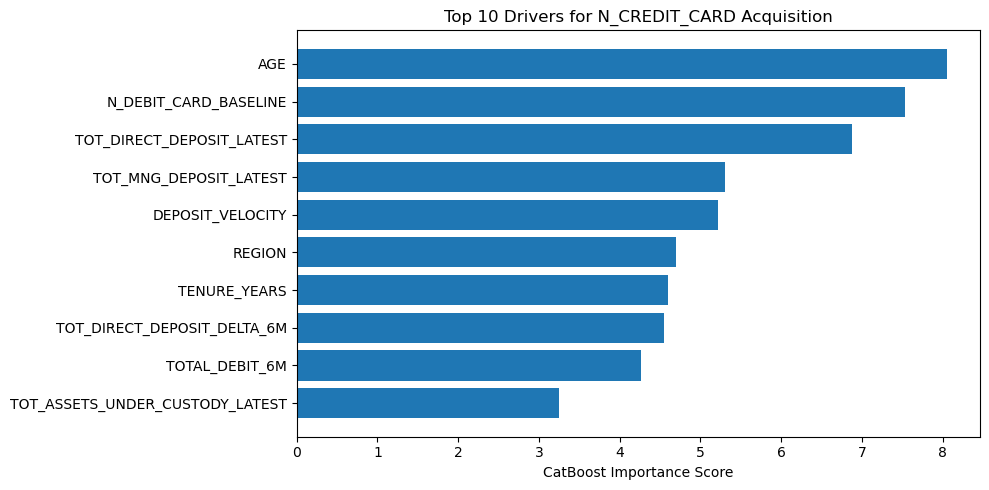


--- Generating EV-Driven Marketing Artifact ---
Total OOT Prospects: 13307
Profitable Prospects to Target (EV > $0): 2096 (15.8%)
Projected Campaign ROI: $12,609.37
Buyers captured in Target List: 89 / 216 (41.2%)

File Saved: Target_List_EV_N_CREDIT_CARD.csv


In [33]:
# 1. Extract Feature Importance
feature_importances = base_model.get_feature_importance()
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1], color='#1f77b4')
plt.title(f'Top 10 Drivers for {CONFIG["target_product"]} Acquisition')
plt.xlabel('CatBoost Importance Score')
plt.tight_layout()
plt.show()

# 2. Expected Value (EV) Driven Marketing Artifact Generation
print("\n--- Generating EV-Driven Marketing Artifact ---")
deployment_df = pd.DataFrame({
    'CUSTOMER_ID': test_df['CUSTOMER_ID'],
    'ACTUAL_TARGET': y_test,
    'PROPENSITY_SCORE': test_probs
})

# Calculate Expected Value per customer: (Probability * LTV) - Cost
cost = CONFIG['marketing']['campaign_cost_per_contact']
ltv = CONFIG['marketing']['expected_ltv_credit_card']

deployment_df['EXPECTED_VALUE'] = (deployment_df['PROPENSITY_SCORE'] * ltv) - cost

# Filter for strictly profitable prospects (EV > 0)
profitable_prospects = deployment_df[deployment_df['EXPECTED_VALUE'] > 0].sort_values(by='EXPECTED_VALUE', ascending=False)

total_buyers = deployment_df['ACTUAL_TARGET'].sum()
captured_buyers = profitable_prospects['ACTUAL_TARGET'].sum()

print(f"Total OOT Prospects: {len(deployment_df)}")
print(f"Profitable Prospects to Target (EV > $0): {len(profitable_prospects)} ({len(profitable_prospects)/len(deployment_df)*100:.1f}%)")
print(f"Projected Campaign ROI: ${(profitable_prospects['EXPECTED_VALUE'].sum()):,.2f}")
print(f"Buyers captured in Target List: {captured_buyers} / {total_buyers} ({(captured_buyers/total_buyers)*100:.1f}%)")

output_file = f"Target_List_EV_{CONFIG['target_product']}.csv"
profitable_prospects[['CUSTOMER_ID', 'PROPENSITY_SCORE', 'EXPECTED_VALUE']].to_csv(output_file, index=False)
print(f"\nFile Saved: {output_file}")

## 8 (Deployment)

In [34]:
def score_current_base(current_anchor, obs_len, model, feature_cols, target_col):
    """
    Production inference function. Filters for eligible customers using 
    the stability rule before scoring them.
    """
    print(f"Scoring active base for anchor: {current_anchor}...")
    
    # 1. Calculate observation window dynamically
    year, month = current_anchor // 100, current_anchor % 100
    obs_window = []
    for i in range(obs_len - 1, -1, -1):
        m = month - i
        y = year + (m - 1) // 12
        m = (m - 1) % 12 + 1
        obs_window.append(y * 100 + m)
        
    # 2. Filter for ELIGIBLE customers (The Stability Rule)
    obs_data = products_df[products_df['MONTH'].isin(obs_window)][['CUSTOMER_ID', target_col]]
    stability_agg = obs_data.groupby('CUSTOMER_ID')[target_col].agg(['min', 'max']).reset_index()
    
    # Only keep customers whose product count was completely stable across the 6 months
    active_customers = stability_agg[stability_agg['min'] == stability_agg['max']][['CUSTOMER_ID']]
    print(f"Eligible targets after stability filter: {len(active_customers)}")
    
    # 3. Build Features (Reusing your domain modules)
    tf_features = build_transfer_features(transfers_df, active_customers, obs_window)
    wealth_features = build_wealth_features(wealth_df, active_customers, obs_window)
    prod_features = build_product_features(products_df, active_customers, current_anchor)
    
    # 4. Assemble
    master = active_customers.merge(tf_features, on='CUSTOMER_ID', how='left')
    master = master.merge(wealth_features, on='CUSTOMER_ID', how='left')
    master = master.merge(prod_features, on='CUSTOMER_ID', how='left')
    master = master.merge(clients_df, on='CUSTOMER_ID', how='left')
    
    master = master.fillna(0)
    
    # 5. Score using the trained calibrated model
    X_score = master[feature_cols] 
    master['PROPENSITY_SCORE'] = model.predict_proba(X_score)[:, 1]
    
    return master[['CUSTOMER_ID', 'PROPENSITY_SCORE']].sort_values(by='PROPENSITY_SCORE', ascending=False)


deployment_scores = score_current_base(
     201903, 
     CONFIG["timeline"]["obs_window_months"], 
     calibrated_model, 
     features,
     CONFIG["target_product"]
 )



Scoring active base for anchor: 201903...
Eligible targets after stability filter: 13582


In [35]:
print(deployment_scores.head(10))

      CUSTOMER_ID  PROPENSITY_SCORE
13330  YM00676152              1.00
6313   LM00874412              1.00
12724  XK00808843              1.00
9519   RN00315797              1.00
3070   FM00930486              1.00
3479   GF00938684              0.99
1524   CR00680481              0.99
6372   LP00369992              0.99
4438   HZ00689470              0.98
1783   DE00785206              0.98


In [36]:
# 1. Calculate Expected Value for the active base
deployment_scores['EXPECTED_VALUE'] = (deployment_scores['PROPENSITY_SCORE'] * CONFIG['marketing']['expected_ltv_credit_card']) - CONFIG['marketing']['campaign_cost_per_contact']

# 2. Filter strictly for chosen customers (EV > 0)
final_chosen_customers = deployment_scores[deployment_scores['EXPECTED_VALUE'] > 0].sort_values(by='EXPECTED_VALUE', ascending=False)

# 3. Export to CSV
file_name = "Final_Target_List_Active_Base_201903.csv"
final_chosen_customers.to_csv(file_name, index=False)

print(f"Success! Exported {len(final_chosen_customers)} profitable customers to {file_name}")
print("\nPreview of the final chosen list:")
print(final_chosen_customers.head())

Success! Exported 2317 profitable customers to Final_Target_List_Active_Base_201903.csv

Preview of the final chosen list:
      CUSTOMER_ID  PROPENSITY_SCORE  EXPECTED_VALUE
13330  YM00676152              1.00          147.50
6313   LM00874412              1.00          147.48
12724  XK00808843              1.00          147.46
9519   RN00315797              1.00          147.28
3070   FM00930486              1.00          147.00


## 9. Sweep Test Different Time Windows


In [37]:
# Define the window combinations to test (Observation Months, Performance Months)
window_grid = [
    (3, 6), # Your current baseline
    (4, 4), # Your current baseline
    (6, 6), # Your current baseline
    (7, 5), # Your current baseline
    (9, 4), # Your current baseline
    (7, 2), # Your current baseline
    (6, 3), # Your current baseline
    (3, 3), # Shorter observation, same prediction horizon
    (4, 2)  # Medium observation, shorter prediction horizon (more impulsive buyers)
]

results = []

for obs_len, perf_len in window_grid:
    print(f"\n{'='*50}")
    print(f"TESTING WINDOW: {obs_len} Month Obs -> {perf_len} Month Perf")
    print(f"{'='*50}")
    
    # 1. Temporarily update the config
    CONFIG["timeline"]["obs_window_months"] = obs_len
    CONFIG["timeline"]["perf_window_months"] = perf_len
    
    # 2. Rebuild the datasets
    print("Building datasets...")
    train_sweep = build_master_dataset(CONFIG["timeline"]["train_anchors"], CONFIG)
    valid_sweep = build_master_dataset(CONFIG["timeline"]["valid_anchors"], CONFIG)
    test_sweep  = build_master_dataset(CONFIG["timeline"]["test_anchors"], CONFIG)
    
    # 3. Setup Features
    features_sweep = [col for col in train_sweep.columns if col not in ['CUSTOMER_ID', 'TARGET', 'COHORT_MONTH']]
    
    X_train_s, y_train_s = train_sweep[features_sweep], train_sweep['TARGET']
    X_valid_s, y_valid_s = valid_sweep[features_sweep], valid_sweep['TARGET']
    X_test_s,  y_test_s  = test_sweep[features_sweep],  test_sweep['TARGET']
    
    # 4. Train Model
    print("Training CatBoost...")
    sweep_model = CatBoostClassifier(
        iterations=500, # Lowered slightly for faster sweeping
        learning_rate=0.05,
        depth=6,
        eval_metric='PRAUC',
        random_seed=42,
        verbose=0 # Silence the output for the sweep
    )
    
    sweep_model.fit(
        X_train_s, y_train_s,
        cat_features=['REGION', 'GENDER'],
        eval_set=(X_valid_s, y_valid_s),
        early_stopping_rounds=50
    )
    
    # 5. Evaluate Lift
    test_probs_s = sweep_model.predict_proba(X_test_s)[:, 1]
    
    deployment_df_s = pd.DataFrame({
        'ACTUAL_TARGET': y_test_s,
        'PROPENSITY_SCORE': test_probs_s
    }).sort_values(by='PROPENSITY_SCORE', ascending=False)

    top_cutoff_s = int(len(deployment_df_s) * 0.10)
    top_prospects_s = deployment_df_s.head(top_cutoff_s)

    total_buyers_s = deployment_df_s['ACTUAL_TARGET'].sum()
    captured_buyers_s = top_prospects_s['ACTUAL_TARGET'].sum()
    
    # Handle edge case where no buyers exist to avoid division by zero
    if total_buyers_s > 0:
        capture_rate_s = captured_buyers_s / total_buyers_s
        lift_s = capture_rate_s / 0.10
    else:
        capture_rate_s = 0
        lift_s = 0
        
    print(f"Total Buyers: {total_buyers_s}")
    print(f"Captured in Top 10%: {captured_buyers_s}")
    print(f"Marketing Lift: {lift_s:.2f}x")
    
    results.append({
        'Obs_Window': obs_len,
        'Perf_Window': perf_len,
        'Lift': lift_s,
        'Total_Buyers': total_buyers_s,
        'Captured_Buyers': captured_buyers_s
    })

# Summarize Results
print("\n\n--- SWEEP RESULTS ---")
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))


TESTING WINDOW: 3 Month Obs -> 6 Month Perf
Building datasets...
Training CatBoost...
Total Buyers: 303
Captured in Top 10%: 149
Marketing Lift: 4.92x

TESTING WINDOW: 4 Month Obs -> 4 Month Perf
Building datasets...
Training CatBoost...
Total Buyers: 300
Captured in Top 10%: 110
Marketing Lift: 3.67x

TESTING WINDOW: 6 Month Obs -> 6 Month Perf
Building datasets...
Training CatBoost...
Total Buyers: 295
Captured in Top 10%: 165
Marketing Lift: 5.59x

TESTING WINDOW: 7 Month Obs -> 5 Month Perf
Building datasets...
Training CatBoost...
Total Buyers: 294
Captured in Top 10%: 148
Marketing Lift: 5.03x

TESTING WINDOW: 9 Month Obs -> 4 Month Perf
Building datasets...
Training CatBoost...
Total Buyers: 288
Captured in Top 10%: 121
Marketing Lift: 4.20x

TESTING WINDOW: 7 Month Obs -> 2 Month Perf
Building datasets...
Training CatBoost...
Total Buyers: 145
Captured in Top 10%: 29
Marketing Lift: 2.00x

TESTING WINDOW: 6 Month Obs -> 3 Month Perf
Building datasets...
Training CatBoost...
To

In [38]:
print("\n--- Financial ROI Comparison ---")

cost = CONFIG['marketing']['campaign_cost_per_contact']
ltv = CONFIG['marketing']['expected_ltv_credit_card']

# Let's compare your original baseline and the new theoretical champion
compare_grid = [(6, 3), (6, 6)]
financial_results = []

for obs_len, perf_len in compare_grid:
    print(f"\nEvaluating Window: {obs_len} Obs -> {perf_len} Perf")
    
    # Temporarily update config
    CONFIG["timeline"]["obs_window_months"] = obs_len
    CONFIG["timeline"]["perf_window_months"] = perf_len
    
    # Ensure we use valid anchors based on the window length
    if perf_len == 6:
        # Forced to use a highly constrained split due to 13-month dataset limit
        temp_train = [201808]
        temp_test = [201809]
    else:
        temp_train = CONFIG["timeline"]["train_anchors"]
        temp_test = CONFIG["timeline"]["test_anchors"]
        
    train_roi_data = build_master_dataset(temp_train, CONFIG)
    test_roi_data  = build_master_dataset(temp_test, CONFIG)
    
    features_roi = [col for col in train_roi_data.columns if col not in ['CUSTOMER_ID', 'TARGET', 'COHORT_MONTH']]
    
    X_tr, y_tr = train_roi_data[features_roi], train_roi_data['TARGET']
    X_te, y_te = test_roi_data[features_roi],  test_roi_data['TARGET']
    
    # Train
    roi_model = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6, eval_metric='PRAUC', random_seed=42, verbose=0)
    roi_model.fit(X_tr, y_tr, cat_features=['REGION', 'GENDER'])
    
    # Calibrate (Crucial for EV math)
    calibrated_roi = CalibratedClassifierCV(estimator=roi_model, method='sigmoid', cv='prefit')
    calibrated_roi.fit(X_tr, y_tr) # Fitting on train here just for the quick sweep
    
    test_probs_roi = calibrated_roi.predict_proba(X_te)[:, 1]
    
    # Calculate EV
    deployment_df_roi = pd.DataFrame({'ACTUAL_TARGET': y_te, 'PROP_SCORE': test_probs_roi})
    deployment_df_roi['EV'] = (deployment_df_roi['PROP_SCORE'] * ltv) - cost
    
    profitable = deployment_df_roi[deployment_df_roi['EV'] > 0]
    
    total_roi = profitable['EV'].sum()
    buyers_captured = profitable['ACTUAL_TARGET'].sum()
    total_buyers = deployment_df_roi['ACTUAL_TARGET'].sum()
    
    financial_results.append({
        'Window': f"{obs_len}->{perf_len}",
        'Profitable_Targets': len(profitable),
        'Captured_Buyers': f"{buyers_captured} / {total_buyers}",
        'Projected_ROI': f"${total_roi:,.2f}"
    })

print("\n\n--- FINANCIAL SWEEP RESULTS ---")
print(pd.DataFrame(financial_results).to_string(index=False))


--- Financial ROI Comparison ---

Evaluating Window: 6 Obs -> 3 Perf

Evaluating Window: 6 Obs -> 6 Perf


--- FINANCIAL SWEEP RESULTS ---
Window  Profitable_Targets Captured_Buyers Projected_ROI
  6->3                2049        87 / 216    $18,495.41
  6->6                3656       396 / 509    $54,719.17


In [39]:
print("\n--- Temporal Anchor Stability Test (6->3 Window) ---")

# Reset to the stable 6->3 window
CONFIG["timeline"]["obs_window_months"] = 6
CONFIG["timeline"]["perf_window_months"] = 3

# Keep training the same, but test across three different OOT winter months
stability_test_anchors = [201810, 201811, 201812]
stability_results = []

# Build the static training set once
train_stab_data = build_master_dataset([201808, 201809], CONFIG)
features_stab = [col for col in train_stab_data.columns if col not in ['CUSTOMER_ID', 'TARGET', 'COHORT_MONTH']]
X_tr_stab, y_tr_stab = train_stab_data[features_stab], train_stab_data['TARGET']

print("Training base stability model...")
stab_model = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6, eval_metric='PRAUC', random_seed=42, verbose=0)
stab_model.fit(X_tr_stab, y_tr_stab, cat_features=['REGION', 'GENDER'])

for test_month in stability_test_anchors:
    print(f"Testing OOT Anchor: {test_month}...")
    
    test_stab_data = build_master_dataset([test_month], CONFIG)
    X_te_stab, y_te_stab = test_stab_data[features_stab], test_stab_data['TARGET']
    
    test_probs_stab = stab_model.predict_proba(X_te_stab)[:, 1]
    
    # Calculate Lift at 10% for baseline comparison
    deployment_df_stab = pd.DataFrame({'ACTUAL_TARGET': y_te_stab, 'PROP_SCORE': test_probs_stab}).sort_values(by='PROP_SCORE', ascending=False)
    
    top_10_cutoff = int(len(deployment_df_stab) * 0.10)
    top_prospects = deployment_df_stab.head(top_10_cutoff)
    
    total_buyers_stab = deployment_df_stab['ACTUAL_TARGET'].sum()
    captured_buyers_stab = top_prospects['ACTUAL_TARGET'].sum()
    
    lift_stab = (captured_buyers_stab / total_buyers_stab) / 0.10 if total_buyers_stab > 0 else 0
    
    stability_results.append({
        'Test_Month': test_month,
        'Base_Size': len(deployment_df_stab),
        'Total_Buyers': total_buyers_stab,
        'Lift_at_10%': f"{lift_stab:.2f}x"
    })

print("\n\n--- STABILITY SWEEP RESULTS ---")
print(pd.DataFrame(stability_results).to_string(index=False))


--- Temporal Anchor Stability Test (6->3 Window) ---
Training base stability model...
Testing OOT Anchor: 201810...
Testing OOT Anchor: 201811...
Testing OOT Anchor: 201812...


--- STABILITY SWEEP RESULTS ---
 Test_Month  Base_Size  Total_Buyers Lift_at_10%
     201810      13285           259       5.87x
     201811      13307           216       3.38x
     201812      13383           221       2.13x


In [41]:
print("\n--- The Ultimate Normalized Window Sweep ---")

# Strict constraints based on the 13-month dataset
valid_obs_windows = [3, 4, 6, 8]
valid_perf_windows = [1, 2, 3, 4] 
fixed_test_anchor = [201811]

cost = CONFIG['marketing']['campaign_cost_per_contact']
ltv = CONFIG['marketing']['expected_ltv_credit_card']

sweep_results = []

for obs_len in valid_obs_windows:
    for perf_len in valid_perf_windows:
        print(f"\nEvaluating: {obs_len} Month Obs -> {perf_len} Month Perf")
        
        CONFIG["timeline"]["obs_window_months"] = obs_len
        CONFIG["timeline"]["perf_window_months"] = perf_len
        
        # Dynamically set training anchors to ensure no overlap with the test anchor
        CONFIG["timeline"]["train_anchors"] = [201808, 201809] if obs_len <= 6 else [201810]
        
        # 1. Build Data
        try:
            train_data = build_master_dataset(CONFIG["timeline"]["train_anchors"], CONFIG)
            test_data  = build_master_dataset(fixed_test_anchor, CONFIG)
        except AssertionError:
            print(f"Skipping {obs_len}->{perf_len} due to dataset length constraints.")
            continue
            
        features_sweep = [col for col in train_data.columns if col not in ['CUSTOMER_ID', 'TARGET', 'COHORT_MONTH']]
        
        X_tr, y_tr = train_data[features_sweep], train_data['TARGET']
        X_te, y_te = test_data[features_sweep],  test_data['TARGET']
        
        # 2. Train Base Model
        model = CatBoostClassifier(iterations=400, learning_rate=0.05, depth=6, eval_metric='PRAUC', random_seed=42, verbose=0)
        model.fit(X_tr, y_tr, cat_features=['REGION', 'GENDER'])
        
        # 3. Calibrate Probabilities
        calibrated = CalibratedClassifierCV(estimator=model, method='sigmoid', cv='prefit')
        calibrated.fit(X_tr, y_tr)
        
        test_probs = calibrated.predict_proba(X_te)[:, 1]
        
        # 4. Calculate Normalized EV
        df_eval = pd.DataFrame({'TARGET': y_te, 'PROB': test_probs})
        df_eval['EV'] = (df_eval['PROB'] * ltv) - cost
        
        profitable_base = df_eval[df_eval['EV'] > 0]
        
        # Avoid division by zero edge cases
        if len(profitable_base) == 0:
            continue
            
        total_ev = profitable_base['EV'].sum()
        buyers_caught = profitable_base['TARGET'].sum()
        total_buyers = df_eval['TARGET'].sum()
        
        # NORMALIZE: How much profit does this model generate per 1,000 customers scored?
        ev_per_1k = (total_ev / len(df_eval)) * 1000
        capture_rate = (buyers_caught / total_buyers) * 100 if total_buyers > 0 else 0
        
        sweep_results.append({
            'Obs_Win': obs_len,
            'Perf_Win': perf_len,
            'Total_Buyers_In_Window': total_buyers,
            'Capture_Rate': f"{capture_rate:.1f}%",
            'EV_per_1000_Scored': round(ev_per_1k, 2)
        })

# Display Results
final_df = pd.DataFrame(sweep_results).sort_values(by='EV_per_1000_Scored', ascending=False)
print("\n\n--- FINAL NORMALIZED SWEEP RESULTS ---")
print(final_df.to_string(index=False))


--- The Ultimate Normalized Window Sweep ---

Evaluating: 3 Month Obs -> 1 Month Perf

Evaluating: 3 Month Obs -> 2 Month Perf

Evaluating: 3 Month Obs -> 3 Month Perf

Evaluating: 3 Month Obs -> 4 Month Perf

Evaluating: 4 Month Obs -> 1 Month Perf

Evaluating: 4 Month Obs -> 2 Month Perf

Evaluating: 4 Month Obs -> 3 Month Perf

Evaluating: 4 Month Obs -> 4 Month Perf

Evaluating: 6 Month Obs -> 1 Month Perf

Evaluating: 6 Month Obs -> 2 Month Perf

Evaluating: 6 Month Obs -> 3 Month Perf

Evaluating: 6 Month Obs -> 4 Month Perf

Evaluating: 8 Month Obs -> 1 Month Perf

Evaluating: 8 Month Obs -> 2 Month Perf

Evaluating: 8 Month Obs -> 3 Month Perf

Evaluating: 8 Month Obs -> 4 Month Perf


--- FINAL NORMALIZED SWEEP RESULTS ---
 Obs_Win  Perf_Win  Total_Buyers_In_Window Capture_Rate  EV_per_1000_Scored
       3         4                     303        62.0%             2166.88
       6         4                     295        60.0%             2104.55
       4         4           